# Logistic Regression

In [1]:
#Importamos todas las librerias a usar
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#### Proceso de ETL y Comprension del Dataset

In [4]:
#Cargamos el Conjunto de Datos

df = pd.read_csv('/workspaces/P15-Logistic-Regression/data/raw/bank-marketing-campaign-data.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
# Obtenemos informacion del Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
#Verificamos Valores unicos y existencia de duplicados
df.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

In [7]:
df.duplicated().sum()


np.int64(12)

In [8]:
df.rename(columns={'default':'current_credit'}, inplace=True)
df

,age,job,marital,education,current_credit,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [9]:
#Eliminamos los valores duplicados
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(41176, 21)

In [10]:
#Verificamos Porcentaje de Si / No de la Variable Target
n = df['y'].loc[df['y']=='no'].count()
y = df['y'].loc[df['y']=='yes'].count()

u = n+y

Pn = (n/u)*100
Py = (y/u)*100

Pn, Py

(np.float64(88.73372838546726), np.float64(11.266271614532737))

In [11]:
#Agrupamos todas las Variables Numericas y Categoricas
num = df.select_dtypes(include='number').columns
cat = df.select_dtypes(include='str').columns



#### 1. Analisis Univariante

In [12]:
#Analisis Univariante Numerico
df[num].nunique()


age                 78
duration          1544
campaign            42
pdays               27
previous             8
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
dtype: int64

In [13]:
numdf = df[num]
numdf['Target'] = pd.factorize(df['y'])[0]
numdf.head()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Target
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0


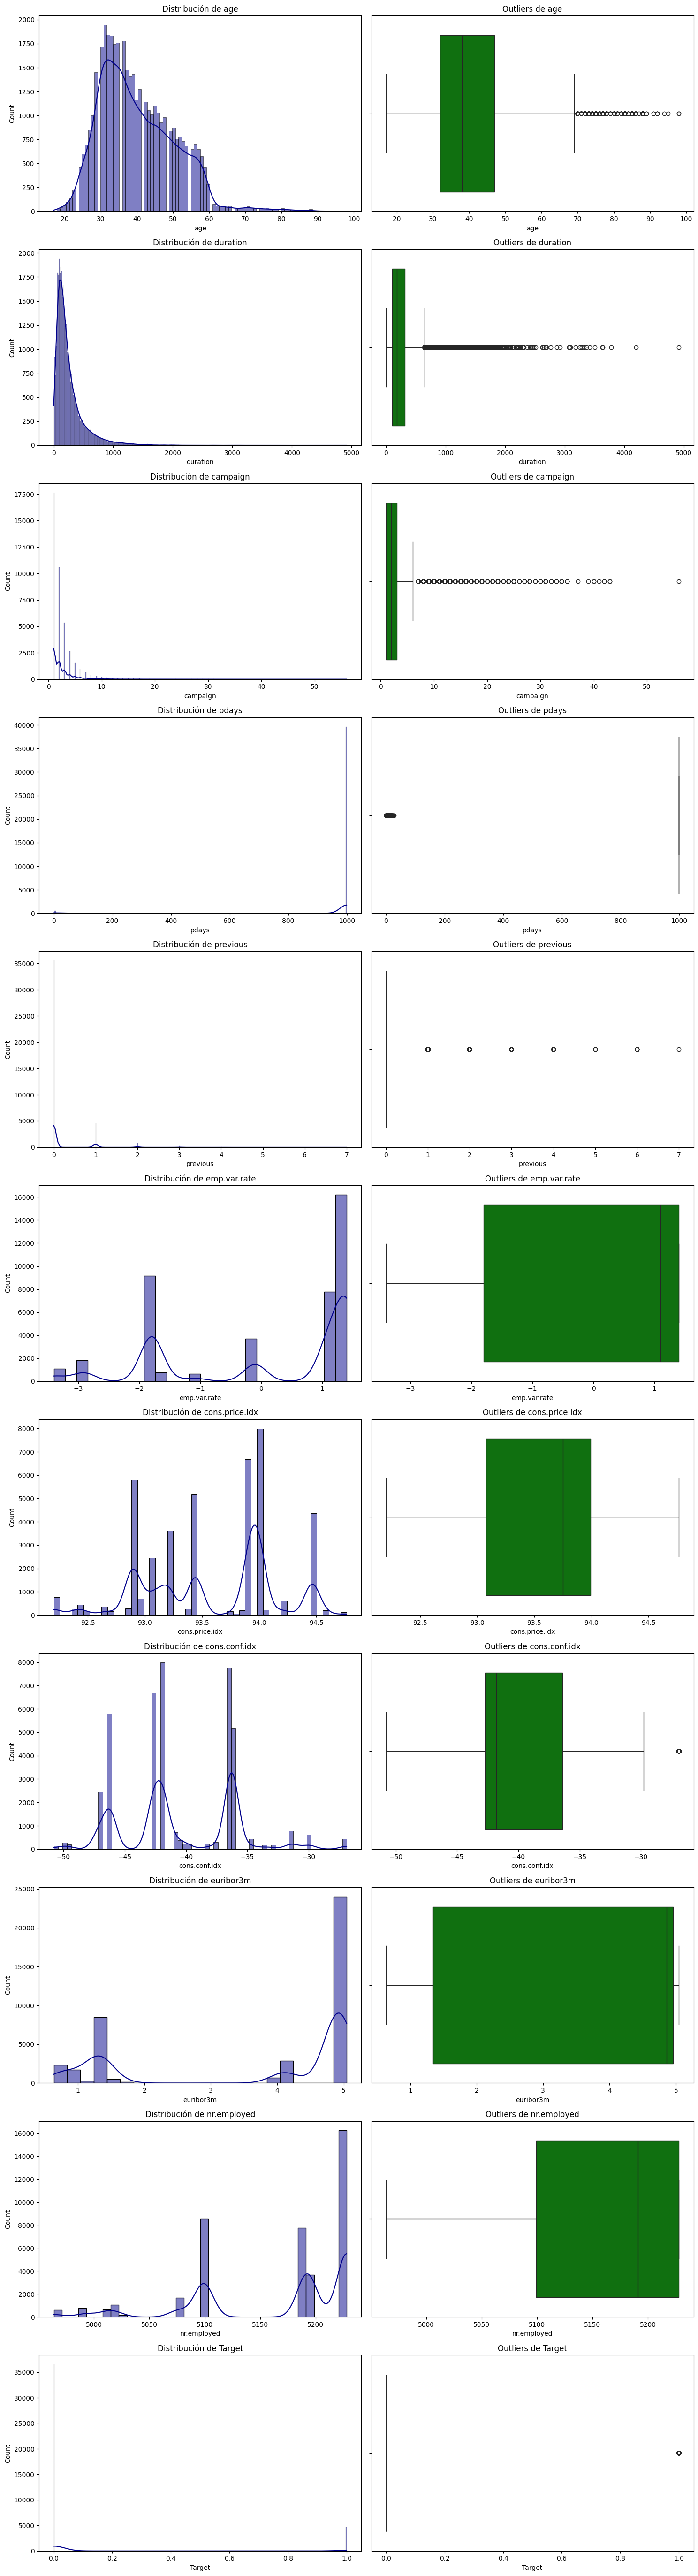

In [39]:
#Definimos una Funcion de Visualizacion de Analisis Univariable

def uninum(df):
    num = df.select_dtypes(include='number').columns
    vars = len(num)
    
    fig, axes = plt.subplots(nrows=vars, ncols=2, figsize=(15, 5 * vars))
    fig.subplots_adjust(hspace=0.4)

    for i, col in enumerate(num):
        #1
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color='darkblue')
        axes[i, 0].set_title(f'Distribución de {col}', fontsize=12)
        
        #2
        sns.boxplot(x=df[col], ax=axes[i, 1], color='green')
        axes[i, 1].set_title(f'Outliers de {col}', fontsize=12)

    plt.tight_layout()
    plt.show()

uninum(numdf)

In [14]:
#Analisis Univariante Categorico
df[cat].nunique()

job               12
marital            4
education          8
current_credit     3
housing            3
loan               3
contact            2
month             10
day_of_week        5
poutcome           3
y                  2
dtype: int64

In [15]:
df[cat].columns
catdf = df[cat]
catdf

,job,marital,education,current_credit,housing,loan,contact,month,day_of_week,poutcome,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,no
...,...,...,...,...,...,...,...,...,...,...,...
41171,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,yes
41172,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,no
41173,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,no
41174,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,yes


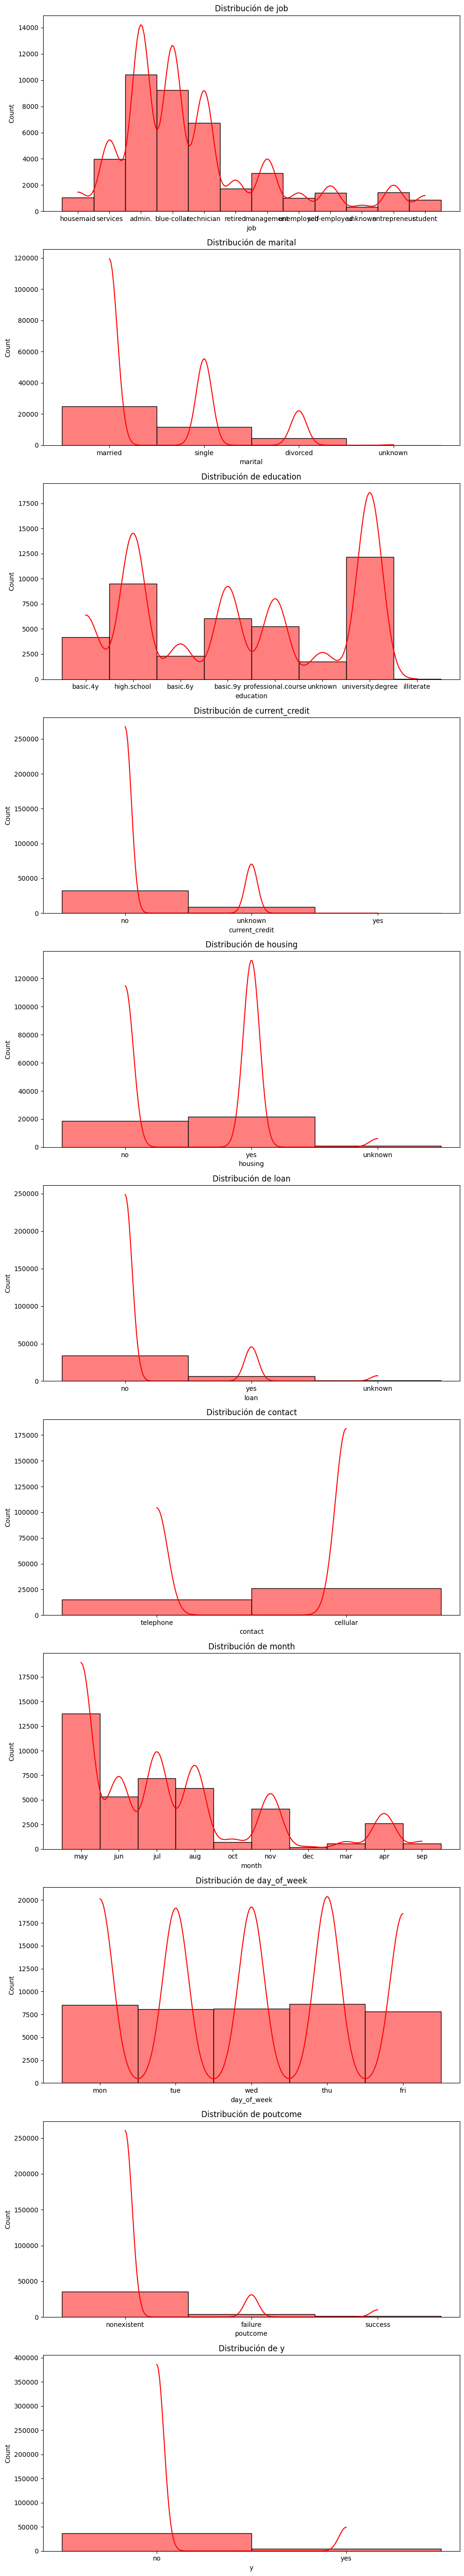

In [42]:
#Definimos una Funcion de Visualizacion de Analisis Categorico Univariable
def unicat(df):
    cat = df.select_dtypes(include='str').columns
    vars = len(cat)

    fig, axes = plt.subplots(nrows=vars, ncols=1, figsize=(10,5*vars))
    fig.subplots_adjust(hspace=0.4)

    for i, col in enumerate(cat):

        sns.histplot(df[col], kde=True, ax=axes[i], color='red')
        axes[i].set_title(f'Distribución de {col}', fontsize=12)

    plt.tight_layout()
    plt.show()


unicat(catdf)


    

#### 2. Analisis Bivariante

In [ ]:
#Definimos una Funcion de Visualizacion de Analisis Numerico Bivariante
def multinum(df, target):
    # 1. Seleccionamos las columnas numéricas (excluyendo el target para las X)
    num = df.select_dtypes(include=['number']).columns
    cols = [c for c in num if c != target]
    n_vars = len(cols)

    # 2. Creamos la cuadrícula: 2 filas y N columnas (una por variable)
    # El tamaño se ajusta según la cantidad de variables
    fig, axes = plt.subplots(nrows=2, ncols=n_vars, figsize=(5 * n_vars, 10))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)

    for i, col in enumerate(cols):
        # --- FILA 1: Regplot (Dispersión + Línea de tendencia) ---
        sns.regplot(data=df, x=col, y=target, ax=axes[0, i], 
                    scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
        axes[0, i].set_title(f'{target} vs {col}', fontsize=12)
        
        # --- FILA 2: Matriz de Correlación Individual ---
        # Calculamos la correlación solo entre la variable actual y el target
       
        
        sns.heatmap(df[[col, target]].corr(), annot=True, fmt='.2f', 
                    cbar=False, ax=axes[1, i], square=True)
        axes[1, i].set_title(f'Correlacion: {col}', fontsize=10)

    plt.tight_layout()
    plt.show()



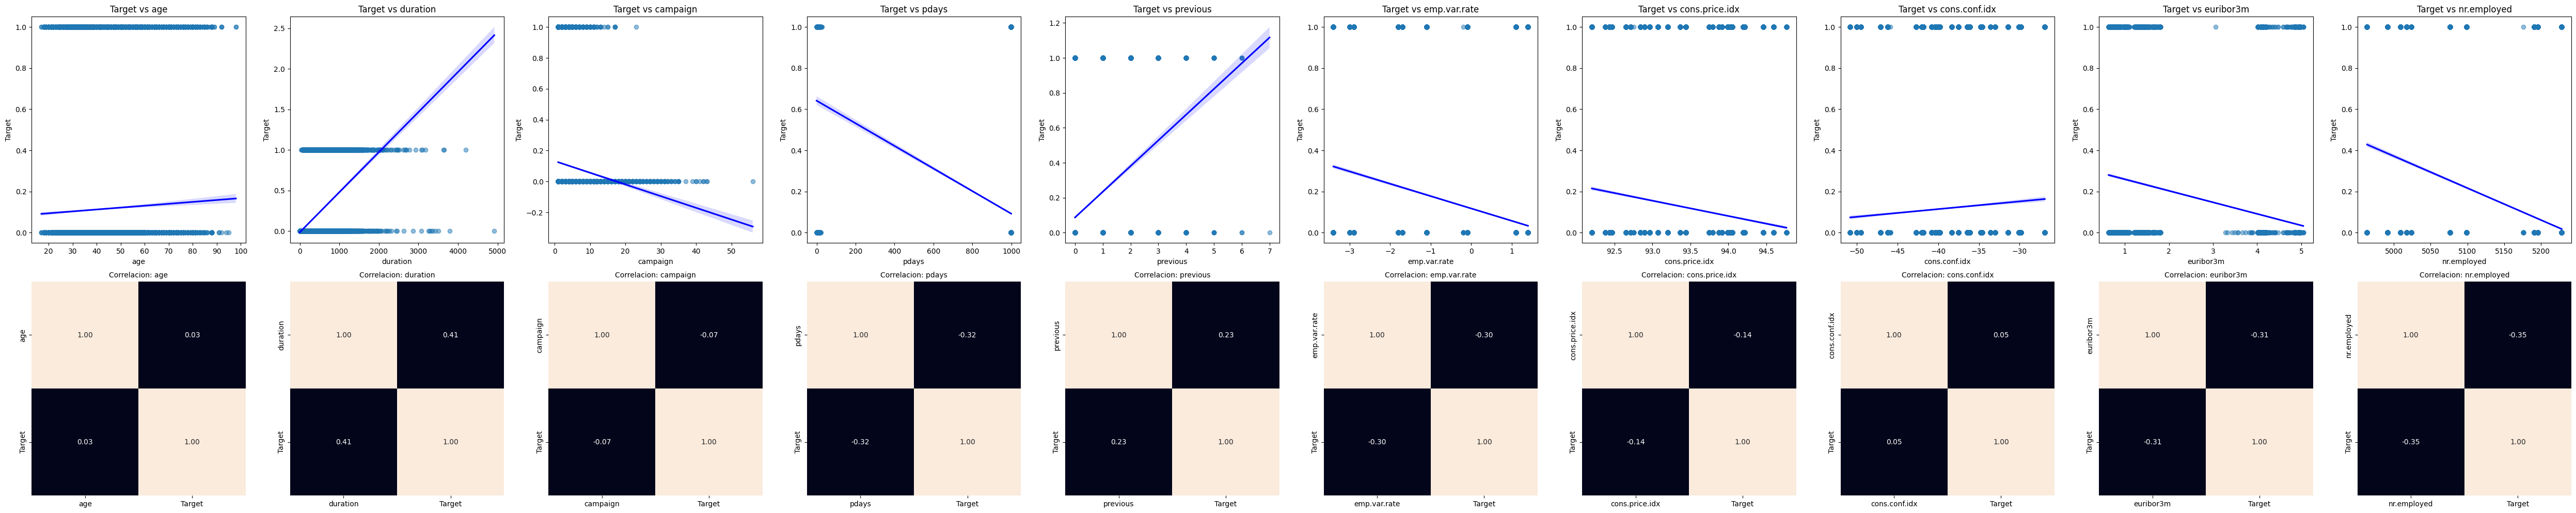

In [44]:
multinum(numdf, 'Target')

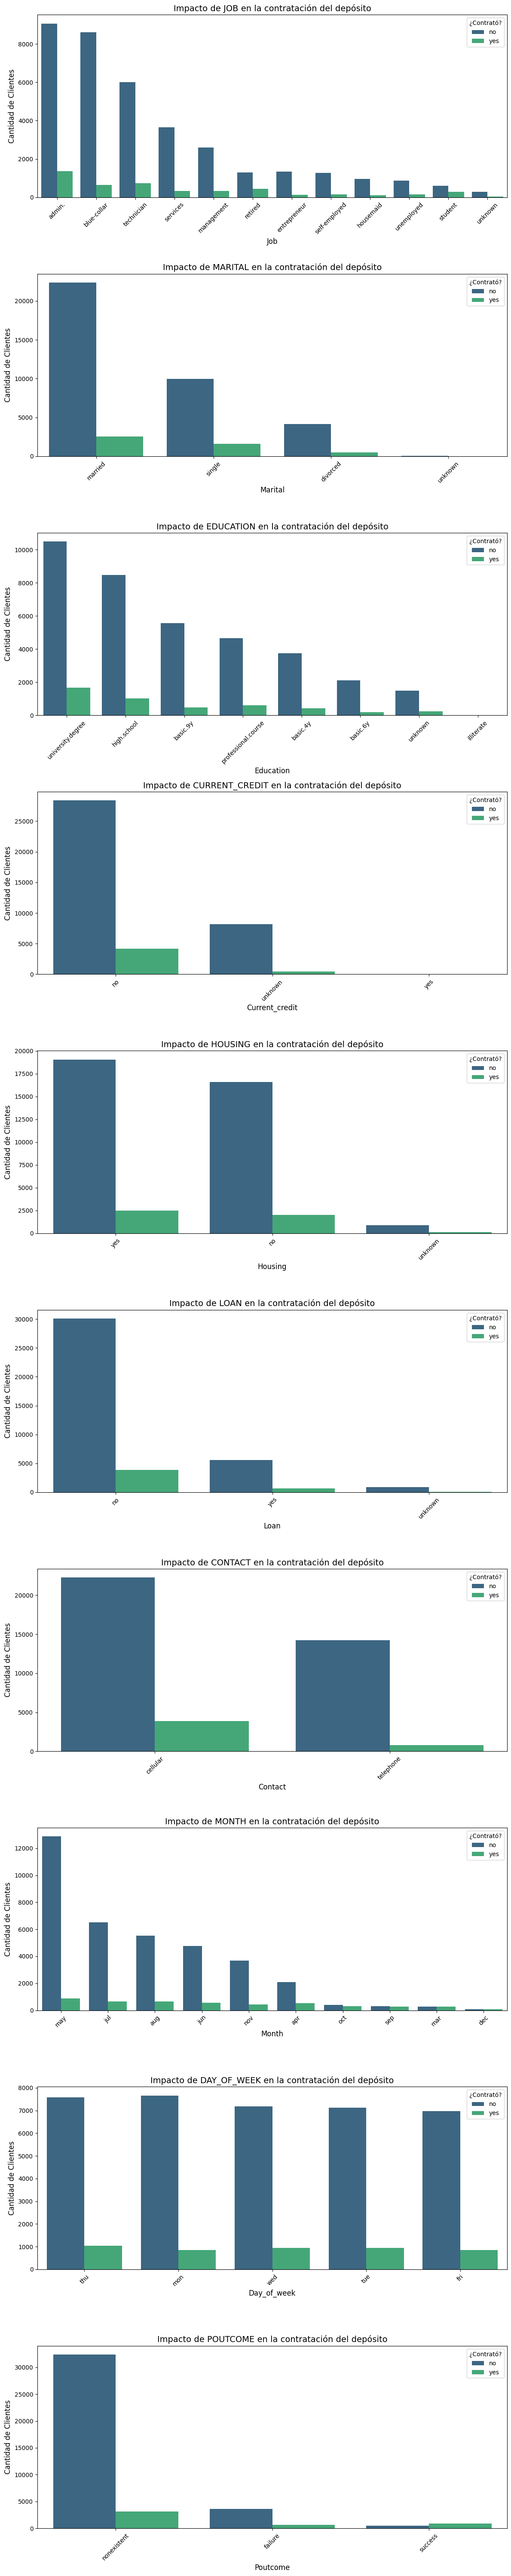

In [ ]:
#Definimos una funcion de Visualizacion Bivariante Categorica

def multicat(df, target='y'):

    cat = df.select_dtypes(include=['str']).columns
    cat = [col for col in cat if col != target]
    
    vars = len(cat)
    
    # 2. Configuramos la cuadrícula: 1 columna por cada variable
    # Usamos un tamaño dinámico para que no se vea todo amontonado
    fig, axes = plt.subplots(nrows=vars, ncols=1, figsize=(12, 6 *vars))
    fig.subplots_adjust(hspace=0.4)

    for i, col in enumerate(cat):
        
        sns.countplot(data=df, x=col, hue=target, ax=axes[i], palette='viridis', 
                      order=df[col].value_counts().index, dodge=True)
        
        axes[i].set_title(f'Impacto de {col.upper()} en la contratación del depósito', fontsize=14)
        axes[i].set_xlabel(col.capitalize(), fontsize=12)
        axes[i].set_ylabel('Cantidad de Clientes', fontsize=12)
        axes[i].legend(title='¿Contrató?', loc='upper right')
        
        # Rotamos las etiquetas del eje X si hay muchos nombres (como en 'job')
        axes[i].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


multicat(catdf, target='y')
    

#### 3. Analisis Multivariante Num-Cat

In [ ]:
# Analisis Multivariante Num-Cat
catdf_encoded = df.select_dtypes(include='str').apply(lambda x: pd.factorize(x)[0])
catdf_encoded

/tmp/ipykernel_78241/2569490241.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catdf_encoded = df.select_dtypes(include='object').apply(lambda x: pd.factorize(x)[0])


,job,marital,education,current_credit,housing,loan,contact,month,day_of_week,poutcome,y
0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,1,1,0,0,0,0,0,0,0
2,1,0,1,0,1,0,0,0,0,0,0
3,2,0,2,0,0,0,0,0,0,0,0
4,1,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
41171,5,0,4,0,1,0,1,5,4,0,1
41172,3,0,4,0,0,0,1,5,4,0,0
41173,5,0,6,0,1,0,1,5,4,0,0
41174,4,0,4,0,0,0,1,5,4,0,1


In [17]:
#Analisis Multivariante Num-Cat
total_df = pd.concat([numdf, catdf_encoded], axis=1)
total_df.drop(columns='Target', inplace=True)
total_df.head()
total_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   duration        41176 non-null  int64  
 2   campaign        41176 non-null  int64  
 3   pdays           41176 non-null  int64  
 4   previous        41176 non-null  int64  
 5   emp.var.rate    41176 non-null  float64
 6   cons.price.idx  41176 non-null  float64
 7   cons.conf.idx   41176 non-null  float64
 8   euribor3m       41176 non-null  float64
 9   nr.employed     41176 non-null  float64
 10  job             41176 non-null  int64  
 11  marital         41176 non-null  int64  
 12  education       41176 non-null  int64  
 13  current_credit  41176 non-null  int64  
 14  housing         41176 non-null  int64  
 15  loan            41176 non-null  int64  
 16  contact         41176 non-null  int64  
 17  month           41176 non-null  int64  
 1

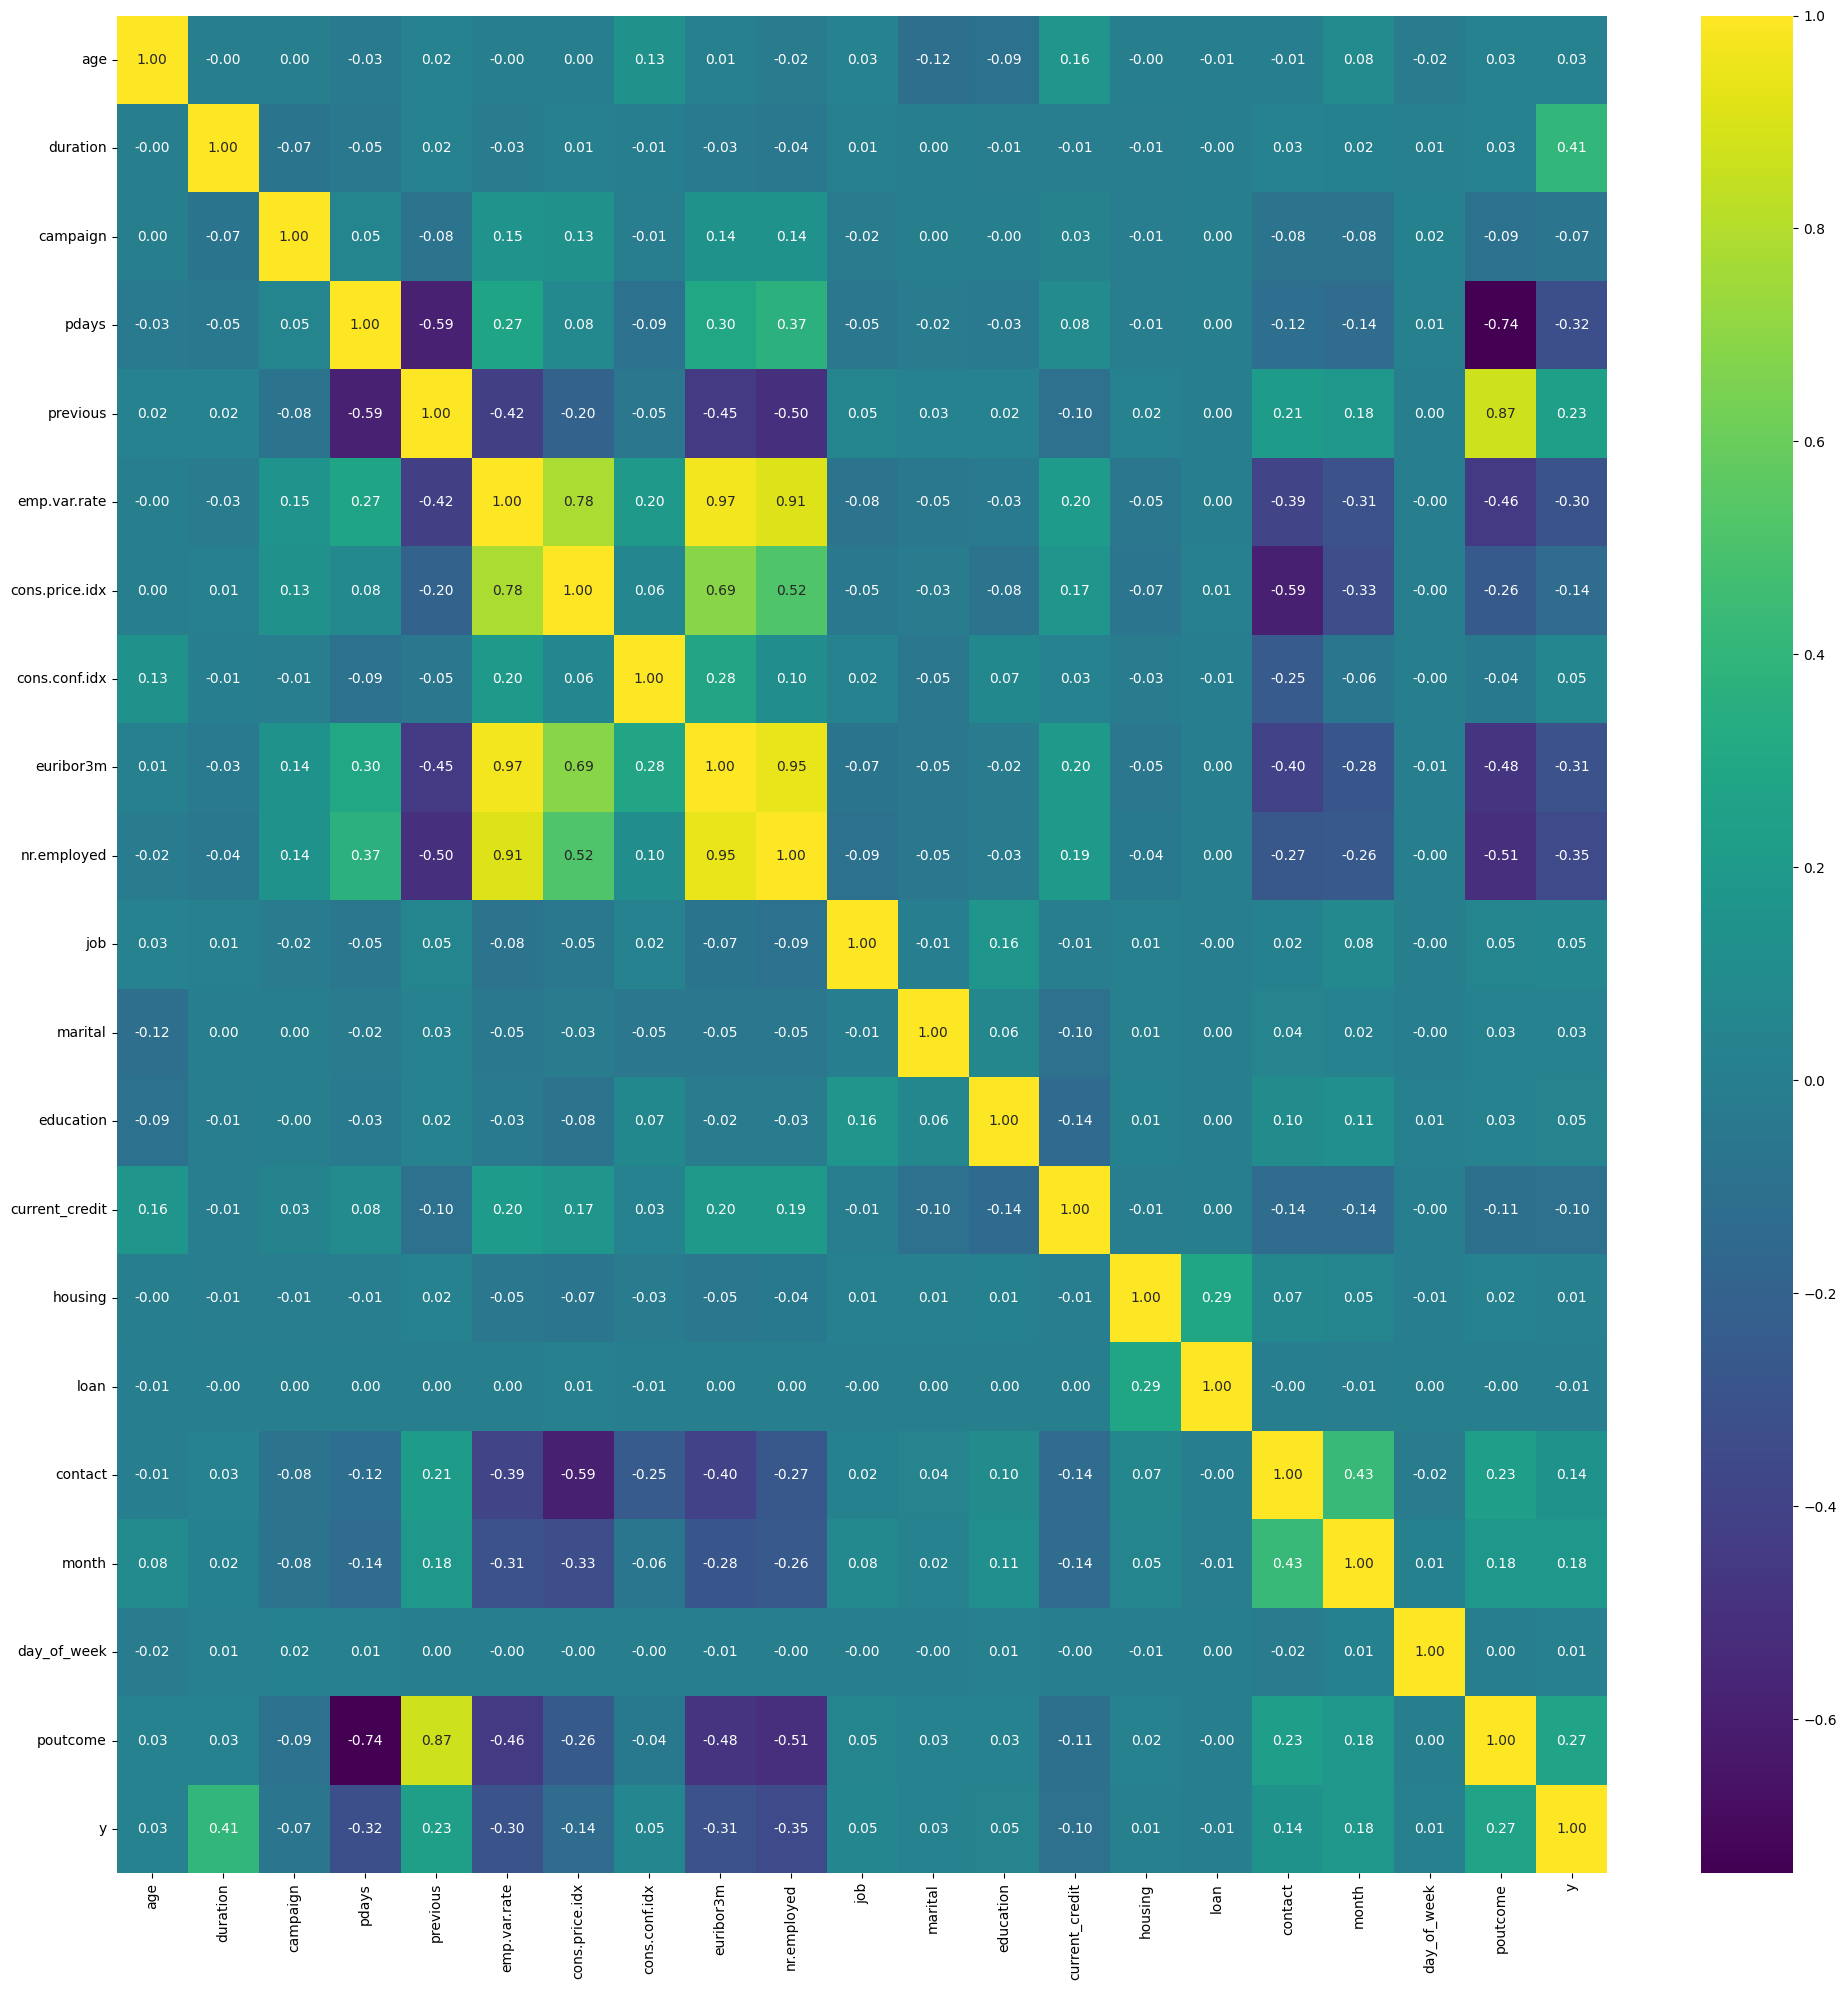

In [48]:
plt.figure(figsize=(20, 20))
sns.heatmap(total_df.corr(), annot= True, fmt='.2f', cmap='viridis')
plt.tight_layout()
plt.show()

### 4. Ingenieria de Caracteristicas (Escalado)

In [21]:
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(total_df)
total_df_scaled = pd.DataFrame(scaled_features, index= df.index, columns=total_df.columns)

total_df_scaled.head()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,marital,education,current_credit,housing,loan,contact,month,day_of_week,poutcome,y
0,0.481481,0.053070,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.493827,0.030297,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,...,0.0,0.142857,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.246914,0.045954,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,...,0.0,0.142857,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0
3,0.283951,0.030704,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,...,0.0,0.285714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.481481,0.062424,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,...,0.0,0.142857,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0


### 5. Seleccion de Caracteristicas

In [24]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split

x = total_df_scaled.drop(columns='y')
y = total_df_scaled['y']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

sm = SelectKBest(chi2, k=5)
sm.fit(x_train, y_train)

sf = sm.get_support(indices=True)

x_train_sel = pd.DataFrame(sm.transform(x_train), columns=x_train.columns[sf])
x_test_sel = pd.DataFrame(sm.transform(x_test), columns=x_test.columns[sf])

x_train_sel.head()


,previous,emp.var.rate,euribor3m,nr.employed,poutcome
0,0.0,1.000000,0.980503,1.000000,0.0
1,0.0,1.000000,0.958966,1.000000,0.0
2,0.0,1.000000,0.981410,1.000000,0.0
3,0.0,0.937500,0.958059,0.859735,0.0
4,0.0,0.333333,0.148946,0.512287,0.0


In [2]:
#Guardamos los datos de entrenamiento en Data Processed
import openpyxl 

x_train_sel['y']=list(y_train)
x_test_sel['y']=list(y_test)

x_train_sel.to_excel('/workspaces/P15-Logistic-Regression/data/processed/clean_train.xlsx') 
x_test_sel.to_excel('/workspaces/P15-Logistic-Regression/data/processed/clean_test.xlsx')


NameError: name 'y_train' is not defined

### 6. Entrenamiento del Modelo de Regresion Logistica

In [4]:
train_data = pd.read_excel('/workspaces/P15-Logistic-Regression/data/processed/clean_train.xlsx')
test_data = pd.read_excel('/workspaces/P15-Logistic-Regression/data/processed/clean_test.xlsx')

Xtrain = train_data.drop(columns='y')
ytrain = train_data['y']
Xtest = test_data.drop(columns='y')
ytest = test_data['y']

Xtrain.head()

,Unnamed: 0,previous,emp.var.rate,euribor3m,nr.employed,poutcome
0,0,0.0,1.000000,0.980503,1.000000,0.0
1,1,0.0,1.000000,0.958966,1.000000,0.0
2,2,0.0,1.000000,0.981410,1.000000,0.0
3,3,0.0,0.937500,0.958059,0.859735,0.0
4,4,0.0,0.333333,0.148946,0.512287,0.0


In [5]:
#Entrenamiento y Ajuste del Modelo Base
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(Xtrain, ytrain)

/workspaces/P15-Logistic-Regression/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
#Primera Prediccion del Modelo
ypred = model.predict(Xtest)
ypred

array([0, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [7]:
#Evaluacion de Rendimiento del Modelo Base
accuracy = accuracy_score(ytest, ypred)
accuracy

0.8930305973773677

In [ ]:
#Evaluacion de Rendimiento con Matriz de Confusion

cm = confusion_matrix(ytest, ypred)
cmdf = pd.DataFrame(cm)

plt.figure(figsize=(5,5))

sns.heatmap(data=cmdf, annot=True, fmt='.2f', cbar=True)

plt.tight_layout()

plt.show()

#### 7. Optimizacion del Modelo con GridSearch

In [14]:
from sklearn.model_selection import GridSearchCV

hyper = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'l1_ratio':[0,1],
    'solver': ['lbfgs', 'liblinear', 'saga', 'newton-cg', 'sag'],
    'max_iter': [25,50,75,100]
}

grid = GridSearchCV(model, hyper, scoring='accuracy', cv=15)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'l1_ratio': [0, 1], 'max_iter': [25, 50, ...], 'solver': ['lbfgs', 'liblinear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",15
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [ ]:
grid.fit(Xtrain, ytrain)

print(f'Los mejores hiperparametros son:', grid.best_params_)

In [ ]:
#Optimizacion 1

model = LogisticRegression()
model.fit(Xtrain, ytrain)

In [ ]:
#Prediccion Opt 1
ypred= model.predict(Xtest)
ypred

In [ ]:
#Evaluacion de la Optimizacion
accuracy = accuracy_score(ytest, ypred)
accuracy

In [ ]:
#Guardamos el Modelo
from pickle import dump

dump(model, open('/workspaces/P15-Logistic-Regression/models/logistic-regression-C-XX-l1_ratio-XX-solver-XX-02-05-2026.sav', wb))